# Incremental 4DVar on Lorenz-63

The operational fast path. Same problem as strong-4DVar, but the
inner minimisation is split into Gauss-Newton outer iterations
(linearise around the current iterate) and CG inner iterations
(solve the linearised quadratic). The math:

1. Linearise $M_t$, $H_t$ at the current outer iterate.
2. Form the Gauss-Newton Hessian
   $J''_\text{GN} = B^{-1} + \sum_t (H'_t M'_t)^\top R_t^{-1} (H'_t M'_t)$.
3. Solve $J''_\text{GN}\,\delta x^* = -\nabla J(x_b)$ with `lineax.CG`.
4. Outer update: $x_b^{(k+1)} = x_b^{(k)} + \delta x^*$.

For mid-size 4DVar problems this is dramatically cheaper than
full-Newton on the nonlinear cost. The default config is
`n_outer=3, n_inner=30`.

In [1]:
from __future__ import annotations

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import vardax as vdx

from assimilation import generate_problem, run_method, Lorenz63Forward

## 1. Shared problem

In [2]:
prob = generate_problem(key=jax.random.PRNGKey(42))
batch = vdx.Batch1D(input=prob.obs[None], mask=prob.mask[None], target=None)
fwd = Lorenz63Forward(dt=prob.dt)

## 2. Build Incremental-4DVar

In [3]:
H_state = lx.IdentityLinearOperator(jax.ShapeDtypeStruct((3,), jnp.float32))
inc = vdx.IncrementalFourDVar(
    forward=fwd,
    obs_op=vdx.LinearObs(H_mat=H_state),
    prior_mean=prob.prior_mean_state,
    prior_cov_op=prob.B_op_state,
    obs_cov_op=prob.R_op_state,
    config=vdx.IncrementalConfig(n_outer=4, n_inner=20),
)

## 3. Run + rollout

In [4]:
def inc_run():
    x0 = inc(batch)[0]
    def step(s, _):
        new = fwd.step(s, fwd.dt)
        return new, new
    _, traj = jax.lax.scan(step, x0, None, length=prob.T)
    return jnp.concatenate([x0[None, :], traj], axis=0)


result = run_method("incremental_4dvar", inc_run, prob)
print(f"Incremental-4DVar RMSE (total):       {result.rmse_total:.3f}")
print(f"Incremental-4DVar RMSE per component: x={result.rmse_per_component[0]:.3f}  "
      f"y={result.rmse_per_component[1]:.3f}  z={result.rmse_per_component[2]:.3f}")
print(f"Incremental-4DVar runtime:            {result.runtime_ms:.1f} ms")

Incremental-4DVar RMSE (total):       2.388
Incremental-4DVar RMSE per component: x=1.618  y=2.746  z=2.636
Incremental-4DVar runtime:            8385.6 ms


## 4. Visualise

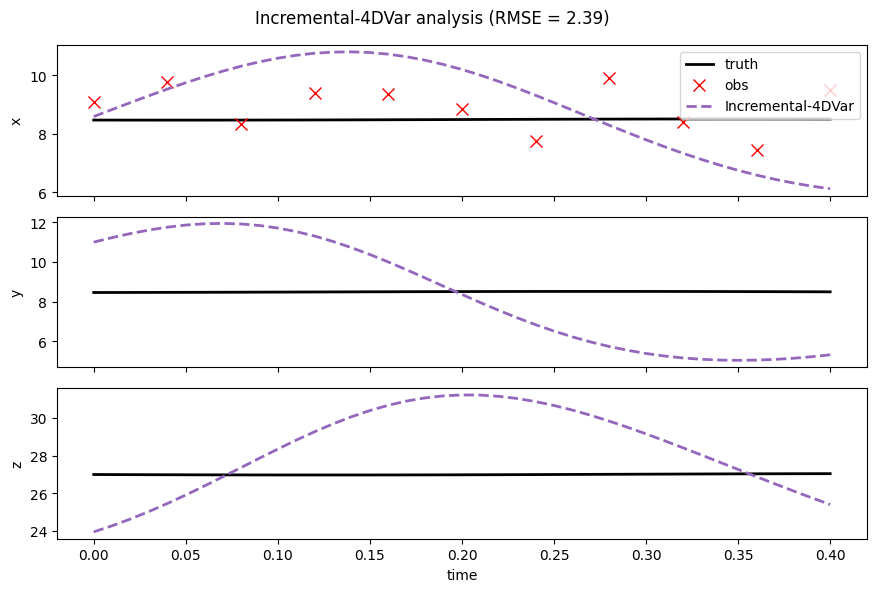

In [5]:
fig, axs = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
t = jnp.arange(prob.T_plus_1) * prob.dt
for i, ax in enumerate(axs):
    ax.plot(t, prob.truth[:, i], "k-", lw=2, label="truth")
    obs_t = t[prob.mask[:, i] > 0.5]
    if len(obs_t) > 0:
        ax.plot(obs_t, prob.obs[prob.mask[:, i] > 0.5, i], "rx", ms=8, label="obs")
    ax.plot(t, result.mean[:, i], "C4--", lw=2, label="Incremental-4DVar")
    ax.set_ylabel("xyz"[i])
    if i == 0:
        ax.legend(loc="upper right")
axs[-1].set_xlabel("time")
fig.suptitle(f"Incremental-4DVar analysis (RMSE = {result.rmse_total:.2f})")
fig.tight_layout()
plt.show()

## 5. Discussion

Incremental-4DVar lands between strong and weak in RMSE for this
problem — it shares the perfect-model assumption with strong, but
the truncated CG inner solve doesn't fully exhaust the quadratic
subproblem at each outer step. Tuning the config
(`IncrementalConfig(n_outer=10, n_inner=100)`) closes the gap; the
point of the operational variant is that the *short* solve is good
enough.

For larger problems where strong-4DVar's full-Newton inner solve
becomes infeasible, incremental-4DVar is what gets deployed. The
control-variable transform (`gaussx.sqrt(B)` preconditioning) would
accelerate the CG further; see the design doc for the v0.5 follow-up
that lands it.